In [18]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

In [2]:
image_path = "../output_videos/cropped_image.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


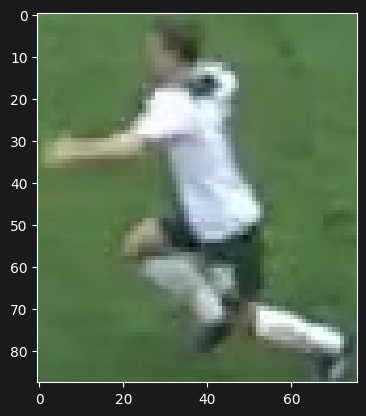

In [3]:
plt.imshow(image)
plt.show()

Take the top half of the image


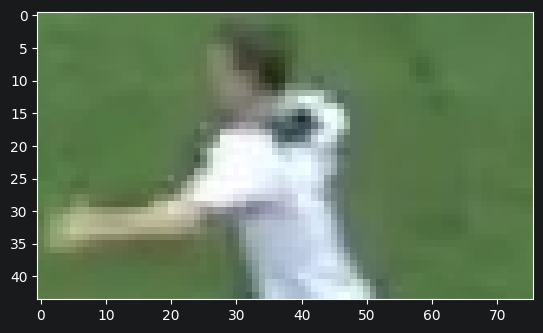

In [4]:
top_half_image = image[0: int(image.shape[0] / 2), :]
plt.imshow(top_half_image)
plt.show()

Separate background from shirt color


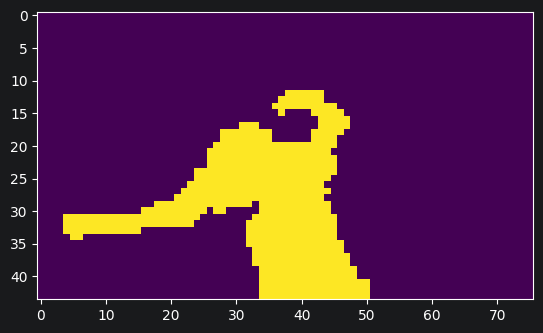

In [21]:
# Reshape image into 2d array
image_2d = top_half_image.reshape(-1, 3)

# Perform k-means clustering with two clusters
kmeans = KMeans(n_clusters=2, random_state=0).fit(image_2d)

# Get the cluster labels
labels = kmeans.labels_

# Reshape the labels into the original image shape
clustered_image = labels.reshape(top_half_image.shape[0], top_half_image.shape[1])

#Display the clustered image
plt.imshow(clustered_image)
plt.show()


In [22]:
corner_clusters = [clustered_image[0, 0], clustered_image[0, -1], clustered_image[-1, 0], clustered_image[-1, -1]]
non_player_cluster = max(set(corner_clusters), key=corner_clusters.count)
print(non_player_cluster)

0


In [23]:
player_cluster = 1 - non_player_cluster
print(player_cluster)

1


In [24]:
kmeans.cluster_centers_[player_cluster]

array([198.9133574 , 209.25812274, 212.1967509 ])